# Make plots of both MOM6 and MITgcm ISOMIP results

Fig 4 and Fig C1 - T,S transects and melt rate and overturning streamfunctions over last 180 days for MOM6 and MITgcm

In [1]:
#from MITgcmutils import mds

#Load required packages
%matplotlib inline
import matplotlib.pyplot as plt
import xarray as xr
from xgcm import Grid
import numpy as np
import cftime
import IPython.display
import cmocean as cm
import sys, os
import warnings
warnings.simplefilter("ignore")
from dask.distributed import Client

from xhistogram.xarray import histogram
import cmcrameri as cmc


In [2]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/41245/status,
Dashboard: /proxy/41245/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45505,Workers: 7
Dashboard: /proxy/41245/status,Total threads: 14
Started: Just now,Total memory: 63.00 GiB
Comm: tcp://127.0.0.1:41833,Total threads: 2
Dashboard: /proxy/46103/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:40625,


Define functions for MITgcm data

In [3]:
base_folder_MIT = '/g/data/x77/cy8964/mitgcm/archive/'

list_folders_MIT = ['run-J10-warm-utide','run-R22-warm-utide', 
                'run-J10-cold-utide','run-R22-cold-utide',
                'run-J10-warm-ustarmin','run-R22-warm-ustarmin',
                'run-J10-cold-ustarmin','run-R22-cold-ustarmin',
                'run-J10-warm-convectivelimitlocal','run-R22-warm-convectivelimitlocal',
                'run-J10-cold-convectivelimitlocal','run-R22-cold-convectivelimitlocal',
                ]
no_configs_MIT = len(list_folders_MIT)

In [4]:
def open_files_MIT_raw(i):
    folder = base_folder_MIT+list_folders_MIT[i]+'/output001/'
    folder1 = base_folder_MIT+list_folders_MIT[i]+'/output000/'
    
    grid = xr.open_dataset(folder1 + 'grid.nc')    
    tave = xr.open_dataset(folder + 'tave.nc')
    shelficetave = xr.open_dataset(folder + 'shelfice_tave.nc')
    shelfsnap = xr.open_dataset(folder + 'shelfsnap.nc')
    return grid, tave, shelficetave, shelfsnap

In [13]:
# compute the overturning streamfunction in density coordinates and time average for data processing to
# reduce size of data
for i in np.arange(len(list_folders_MIT)):
    print(list_folders_MIT[i])
    time_slice = np.arange(-180,0)
    gridnc, tave, shelficetave, shelfsnap = open_files_MIT_raw(i)
    grid = Grid(tave.isel(T = time_slice), coords={'Z': {'center':'Z','outer':'Zl'}, 
                          'X': {'center':'X','outer':'Xp1'},
                          'Y': {'center':'Y','outer':'Yp1'}}, periodic=False)
    u_transport = tave.uVeltave.isel(T = time_slice) * gridnc.dyG * gridnc.HFacW * gridnc.drF
    tAlpha = 3.733E-5
    sBeta = 7.843E-4
    rhoNil = 1027.51
    rho = rhoNil*(sBeta*(tave.Stave.isel(T = time_slice)-(34.2))-tAlpha*(tave.Ttave.isel(T = time_slice)+1))+(rhoNil)
    rho = grid.interp(rho,'X').rename('rho')
    rhobins = np.linspace(1027,1027.85,51) #1027.85,1027
    u_transport_rho = histogram(rho, bins=[rhobins], dim = ['Z'],weights=u_transport)
    print( u_transport_rho.shape)
    Psi = (u_transport_rho.cumsum('rho_bin').sum('Y').mean('T'))/1e6
    Psi.attrs['description'] = 'Overturning streamfunction (Sv) in density (rho_bins) space averaged using daily output over last 180 days in file https://github.com/claireyung/stratification-feedback-param-paper/blob/master/combined-ISOMIP-MITgcmMOM6-Copy1.ipynb'
    Psi.to_netcdf(base_folder_MIT+list_folders_MIT[i]+'/output001/Overturning_streamfunc_rho_steadymean.nc')

run-J10-warm-utide
(180, 42, 241, 50)
run-R22-warm-utide
(180, 42, 241, 50)
run-J10-cold-utide
(180, 42, 241, 50)
run-R22-cold-utide
(180, 42, 241, 50)
run-J10-warm-ustarmin
(180, 42, 241, 50)
run-R22-warm-ustarmin
(180, 42, 241, 50)
run-J10-cold-ustarmin
(180, 42, 241, 50)
run-R22-cold-ustarmin
(180, 42, 241, 50)
run-J10-warm-convectivelimitlocal
(180, 42, 241, 50)
run-R22-warm-convectivelimitlocal
(180, 42, 241, 50)
run-J10-cold-convectivelimitlocal
(180, 42, 241, 50)
run-R22-cold-convectivelimitlocal
(180, 42, 241, 50)


In [5]:
def open_files_MIT(i):
    folder = base_folder_MIT+list_folders_MIT[i]+'/output001/'
    folder1 = base_folder_MIT+list_folders_MIT[i]+'/output000/'
    
    grid = xr.open_dataset(folder1 + 'grid.nc')    
    tave = xr.open_dataset(folder + 'tave_steadymean.nc').isel(T = 0)
    shelficetave = xr.open_dataset(folder + 'shelfice_tave_steadymean.nc').isel(T = 0)
    shelfsnap = xr.open_dataset(folder + 'shelfsnap_steadymean.nc').isel(T = 0)
    return grid, tave, shelficetave, shelfsnap

In [6]:
# melt in kg/m^2/s to m/yr = multiply by #seconds per year, divide by rho_0
s_to_yr = 365*24*3600
rho0 = 1000

In [7]:
def plot_transect_MIT(ax, i, y, var, vmin, vmax, cmap):
    grid, tave, shelficetave, shelfsnap = open_files_MIT(i)
    if var == 'vVeltave':
        plotvar = tave[var].isel(Yp1 = y)
        X = tave.X
    elif var == 'uVeltave':
        plotvar = tave[var].isel(Y = y)
        X = tave.Xp1
    else:
        plotvar = tave[var].isel(Y = y)
        X = tave.X

    plotvar = plotvar.where(plotvar !=0)
    mesh = ax.pcolormesh(
    1e-3 * X, -plotvar.Z.values, plotvar.values, 
    cmap=cmap, vmin=vmin, vmax=vmax, shading='nearest')
    ax.set_title(var+', '+list_folders_MIT[i])
    ax.set_ylabel('Depth (m)')
    ax.set_xlabel('x (km)')
    ax.set_ylim(720,0)
    return mesh
        
def plot_melt_MIT(ax, i, vmin, vmax):
    grid, tave, shelficetave, shelfsnap = open_files_MIT(i)
    melt = -s_to_yr/rho0*shelficetave.fwFluxtave
    mesh = ax.pcolormesh(
    1e-3 * melt.X, 1e-3 * melt.Y, melt.values, 
    cmap=cm.cm.balance, vmin=vmin, vmax=vmax, shading='nearest')
    #plt.colorbar(mesh, ax = ax, label = 'melt, m/yr')
    ax.set_title('melt, '+list_folders_MIT[i])
    ax.set_ylabel('y (km)')
    ax.set_xlabel('x (km)')
    print('Total Melt for '+list_folders_MIT[i]+' experiment = '+str(melt.where(melt !=0).mean().values)+' m/yr')
    return mesh, melt.where(melt!=0).mean()
    
def plot_melt_timeseries_MIT(ax, i):
    grid, tave, shelficetave, shelfsnap = open_files_MIT(i)
    time = np.arange(len(shelficetave.fwFluxtave))
    melt = -s_to_yr/rho0*shelficetave.fwFluxtave.where(shelficetave.fwFluxtave !=0).mean(['X','Y'])
    print(list_folders_MIT[i])
    print('melt at day -1 = '+str(melt.isel(T = -1).values))
    ax.plot(time, melt, label = list_folders_MIT[i])
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Melt, averaged over shelf (m/yr)')

def compute_melt_MIT(i):
    grid, tave, shelficetave, shelfsnap = open_files_MIT(i)
    melt = -s_to_yr/rho0*shelficetave.fwFluxtave
    melt = melt.where(melt!=0).mean(['X','Y']).values
    return melt

In [8]:
# Old versions before saving processed data
# def plot_rhooverturning_MITnew(ax, i, time_slice, vmin, vmax):
#     gridnc, tave, shelficetave, shelfsnap = open_files_MIT(i)
#     grid = Grid(tave.isel(T = time_slice), coords={'Z': {'center':'Z','outer':'Zl'}, 
#                           'X': {'center':'X','outer':'Xp1'},
#                           'Y': {'center':'Y','outer':'Yp1'}}, periodic=False)
#     u_transport = tave.uVeltave.isel(T = time_slice) * gridnc.dyG * gridnc.HFacW * gridnc.drF
#     tAlpha = 3.733E-5
#     sBeta = 7.843E-4
#     rhoNil = 1027.51
#     rho = rhoNil*(sBeta*(tave.Stave.isel(T = time_slice)-(34.2))-tAlpha*(tave.Ttave.isel(T = time_slice)+1))+(rhoNil)
#     rho = grid.interp(rho,'X').rename('rho')
#     rhobins = np.linspace(1027,1027.85,51) #1027.85,1027
#     u_transport_rho = histogram(rho, bins=[rhobins], dim = ['Z'],weights=u_transport)
#     print( u_transport_rho.shape)
#     Psi = (u_transport_rho.cumsum('rho_bin').sum('Y').mean('T'))/1e6
    
#     rhorho,XX,  = np.meshgrid(Psi.rho_bin,Psi.Xp1)
#     cs1 = ax.contour(XX/1e3, rhorho,Psi,levels = np.linspace(vmin, vmax,21), colors = 'k', linewidths = 0.3)
#     cs = ax.contourf(XX/1e3, rhorho,Psi,levels = np.linspace(vmin, vmax,41), cmap = cm.cm.balance,extend = 'both')
#     #plt.colorbar(cs, ax = ax, label = 'Overturning SF (Sv)')
#     ax.set_ylabel('Density (kg/m$^3$)')
#     ax.set_ylim(1027.85,1027)
#     ax.set_xlabel('x (km)')
#     ax.set_title(list_folders_MIT[i])
#     print(list_folders_MIT[i])
#     print('Max Psi = '+str(Psi.max().values)+' Sv')
#     return cs,cs1,Psi.max().values

# def compute_rhooverturning_MIT(i,time_slice):
#     gridnc, tave, shelficetave, shelfsnap = open_files_MIT(i)
#     tave = tave.load()
#     grid = Grid(tave.isel(T = time_slice), coords={'Z': {'center':'Z','outer':'Zl'}, 
#                           'X': {'center':'X','outer':'Xp1'},
#                           'Y': {'center':'Y','outer':'Yp1'}}, periodic=False)
#     u_transport = tave.uVeltave.isel(T = time_slice) * gridnc.dyG * gridnc.HFacW * gridnc.drF
#     tAlpha = 3.733E-5
#     sBeta = 7.843E-4
#     rhoNil = 1027.51
#     rho = rhoNil*(sBeta*(tave.Stave.isel(T = time_slice)-(34.2))-tAlpha*(tave.Ttave.isel(T = time_slice)+1))+(rhoNil)
#     rho = grid.interp(rho,'X').rename('rho')
#     rhobins = np.linspace(1026.75,1027.85,51)
#     u_transport_rho = histogram(rho, bins=[rhobins], dim = ['Z'],weights=u_transport)
#     Psi = (u_transport_rho.cumsum('rho_bin').sum('Y'))/1e6
    
#     Psi_max = Psi.mean('T').max().values
#     Psi_min = Psi.mean('T').min().values
#     if (np.abs(Psi_max) > np.abs(Psi_min)):
#         return Psi_max
#     else:
#         return  Psi_min


def plot_rhooverturning_MITnew(ax, i, vmin, vmax):
    Psi = xr.open_dataset(base_folder_MIT+list_folders_MIT[i]+'/output001/Overturning_streamfunc_rho_steadymean.nc').histogram_rho
    rhorho,XX,  = np.meshgrid(Psi.rho_bin,Psi.Xp1)
    cs1 = ax.contour(XX/1e3, rhorho,Psi,levels = np.linspace(vmin, vmax,21), colors = 'k', linewidths = 0.3)
    cs = ax.contourf(XX/1e3, rhorho,Psi,levels = np.linspace(vmin, vmax,41), cmap = cm.cm.balance,extend = 'both')
    ax.set_ylabel('Density (kg/m$^3$)')
    ax.set_ylim(1027.85,1027)
    ax.set_xlabel('x (km)')
    ax.set_title(list_folders_MIT[i])
    print(list_folders_MIT[i])
    print('Max Psi = '+str(Psi.max().values)+' Sv')
    return cs,cs1,Psi.max().values

def compute_rhooverturning_MIT(i):
    Psi = xr.open_dataset(base_folder_MIT+list_folders_MIT[i]+'/output001/Overturning_streamfunc_rho_steadymean.nc').histogram_rho  
    Psi_max = Psi.mean('T').max().values
    Psi_min = Psi.mean('T').min().values
    if (np.abs(Psi_max) > np.abs(Psi_min)):
        return Psi_max
    else:
        return  Psi_min



In [9]:
list_folders_base = ['layer-thermo-on-warm_CC','layer-thermo-on-cold_CC',
               'layer-thermo-on-warm_SF','layer-thermo-on-cold_SF']
suffixes = ['','-ustarmin','-u01tides','-u005tides','-u001tides','-u02tides','-MK18']
list_folders_MOM6 = []
for n in np.arange(len(suffixes)):
    list_folders_MOM6 = np.append(list_folders_MOM6, [x+suffixes[n] for x in list_folders_base])
print(list_folders_MOM6)

base_folder_MOM6 = '/g/data/x77/cy8964/mom6/archive/'

## define some useful functions
ymax = 720
def open_files_MOM6(i):
    base = base_folder_MOM6 + list_folders_MOM6[i]
    try:
        prog = xr.open_dataset(base + '/output000/prog_steadymean.nc').isel(Time = 0)#,chunks={'Time': 10}).chunk({'Time': 10,'yh':40,'xh':240,'yq':40,'xq':240})
    except FileNotFoundError:
        print('year 1 output')
        prog = xr.open_dataset(base + '/output000/prog__0001_002.nc')
    ocean_geometry = xr.open_dataset(base + "/output000/ocean_geometry.nc")
    return prog, ocean_geometry
def open_ocean_daily_z_MOM6(i):
    base = base_folder_MOM6 + list_folders_MOM6[i]
    prog = xr.open_dataset(base + '/output000/ocean_daily_z_steadymean.nc').isel(time = 0)#,chunks={'time': 10}).chunk({'time': 10,'yh':40,'xh':240,'yq':40,'xq':240})
    return prog
def plot_MOM6(ax,yy0,i,variable,varname,vmin1,vmax1,cmap):
    prog, ocean_static = open_files_MOM6(i)
    grid = Grid(prog,coords={"x":{"center":"xh","outer":"xq"},
                             "y":{"center":"yh","outer":"yq"},
                             "z":{"center":"zl","outer":"zi"}},periodic=False)
    file_name = list_folders_MOM6[i]
    label = file_name
    depth = grid.interp(prog.e,'x')
    lon = ocean_static.geolonb
    dataplot = variable

    xx = lon
    if varname == "uo": dataplot = dataplot[:,:,:-1]
    levels = np.linspace(vmin1, vmax1, 51)
    yy = depth[:,yy0,:]
    z_levels = yy.shape[0]
    yi = np.linspace(0,5000,z_levels) #Dummy, just for have z_levels
    # plot variable in colours
    xi, yyi = np.meshgrid(xx[yy0,:], yi) #We repeat the horizontal part of the grid by the number of levels
    p = ax.pcolormesh(xi,-yy,
                      dataplot[:,yy0,:],vmin = vmin1, vmax = vmax1, cmap = cmap)
    
    ax.set_ylim(ymin=ymax,ymax=0)
    ax.set_ylabel('Depth (m)')
    ax.set_xlabel('x (km)')
    ax.set_title(varname+' , ' +label)
    return p

    
def plot_melt_MOM6(ax,i,vmin1,vmax1,cmap):
    ocean_daily_z = open_ocean_daily_z_MOM6(i)
    file_name = list_folders_MOM6[i]
    label = list_folders_MOM6[i]
    s_to_year = 3600*24*365
    dataplot = ocean_daily_z.melt
    
    p1 = dataplot.plot(ax = ax, cmap = cmap, vmax = vmax1, vmin = vmin1, add_colorbar = False)
    #plt.colorbar(p1, ax = ax, label = 'Melt, [m/yr]')
    ax.set_ylabel('y (km)')
    ax.set_xlabel('x (km)')
    ax.set_title('Melt , ' +label)
    print('Total Melt for '+label+' experiment = '+str(dataplot.where(dataplot !=0).mean().values)+' m/yr')
    return p1, dataplot.where(dataplot!=0).mean()
    
def open_ocean_month_rho2_MOM6(i):
    base = base_folder_MOM6 + list_folders_MOM6[i]
    ocean_month_rho2 = xr.open_dataset(base + '/output000/ocean_month_rho2_steadymean.nc').isel(time = 0)
    return ocean_month_rho2
def plot_rhooverturning_MOM6(ax,i,vmin1,vmax1,cmap):
    prog, ocean_geometry = open_files_MOM6(i)
    ocean_month_rho2 = open_ocean_month_rho2_MOM6(i)
    #ocean_static = open_static(i)
    grid = Grid(ocean_month_rho2,coords={"x":{"center":"xh","outer":"xq"},
                                 "y":{"center":"yh","outer":"yq"},
                                 #"z":{"center":"z_l","outer":"z_i"}},periodic=False)
                                 "z":{"center":"rho2_l","outer":"rho2_i"}},periodic=False)
    file_name = list_folders_MOM6[i]
    label = list_folders_MOM6[i]
    uh = grid.interp(ocean_month_rho2.umo,'x',boundary='extend')

    Psi_overturning = (uh).cumsum('rho2_l').sum('yh', skipna = True)

    dataplot = Psi_overturning/1e6/1035

    cax = ax.contourf(dataplot.xh.values,dataplot.rho2_l.values,dataplot,levels = np.linspace(vmin1, vmax1,41), cmap = cmap, extend = 'both')
    cax2 = ax.contour(dataplot.xh.values,dataplot.rho2_l.values,dataplot,levels = np.linspace(vmin1, vmax1,21),colors = 'k',linewidths = 0.5) 
    ax.set_ylim(1027.85,1027)
    ax.set_ylabel('Density (kgm$^{-3}$)')
    ax.set_xlabel('x (km)')
    ax.set_title('Overturning streamfunction,\n ' +label)
    return cax, cax2, (Psi_overturning/1e6/1035).max().values
def compute_overturning_MOM6(i):
    ocean_month_rho2 = open_ocean_month_rho2_MOM6(i)
    grid = Grid(ocean_month_rho2,coords={"x":{"center":"xh","outer":"xq"},
                                 "y":{"center":"yh","outer":"yq"},
                                 "z":{"center":"rho2_l","outer":"rho2_i"}},periodic=False)
    file_name = list_folders_MOM6[i]
    label = list_folders_MOM6[i]
    uh = grid.interp(ocean_month_rho2.umo,'x',boundary='extend')#*ocean_month_rho2.thkcello

    Psi_overturning = (uh).cumsum('rho2_l').sum('yh', skipna = True)
    s_to_year = 3600*24*365

    max_osf = (Psi_overturning/1e6/1035).max().values
    min_osf = (Psi_overturning/1e6/1035).min().values
    if (np.abs(max_osf) > np.abs(min_osf)):
        return max_osf
    else:
        return min_osf
    ##WHAT IF MIN is neg?
    return max_osf
def compute_melt_MOM6(i):
    ocean_daily_z = open_ocean_daily_z_MOM6(i)
    melt = ocean_daily_z.melt
    melt = melt.where(melt !=0)
    melt = melt.mean(['xT','yT']).values
    return melt


['layer-thermo-on-warm_CC' 'layer-thermo-on-cold_CC'
 'layer-thermo-on-warm_SF' 'layer-thermo-on-cold_SF'
 'layer-thermo-on-warm_CC-ustarmin' 'layer-thermo-on-cold_CC-ustarmin'
 'layer-thermo-on-warm_SF-ustarmin' 'layer-thermo-on-cold_SF-ustarmin'
 'layer-thermo-on-warm_CC-u01tides' 'layer-thermo-on-cold_CC-u01tides'
 'layer-thermo-on-warm_SF-u01tides' 'layer-thermo-on-cold_SF-u01tides'
 'layer-thermo-on-warm_CC-u005tides' 'layer-thermo-on-cold_CC-u005tides'
 'layer-thermo-on-warm_SF-u005tides' 'layer-thermo-on-cold_SF-u005tides'
 'layer-thermo-on-warm_CC-u001tides' 'layer-thermo-on-cold_CC-u001tides'
 'layer-thermo-on-warm_SF-u001tides' 'layer-thermo-on-cold_SF-u001tides'
 'layer-thermo-on-warm_CC-u02tides' 'layer-thermo-on-cold_CC-u02tides'
 'layer-thermo-on-warm_SF-u02tides' 'layer-thermo-on-cold_SF-u02tides'
 'layer-thermo-on-warm_CC-MK18' 'layer-thermo-on-cold_CC-MK18'
 'layer-thermo-on-warm_SF-MK18' 'layer-thermo-on-cold_SF-MK18']


0.3.0
Total Melt for layer-thermo-on-warm_CC experiment = 1.8591536 m/yr
Total Melt for layer-thermo-on-warm_SF experiment = 0.3413243 m/yr
Total Melt for layer-thermo-on-cold_CC experiment = 0.051885907 m/yr
Total Melt for layer-thermo-on-cold_SF experiment = 0.033663128 m/yr


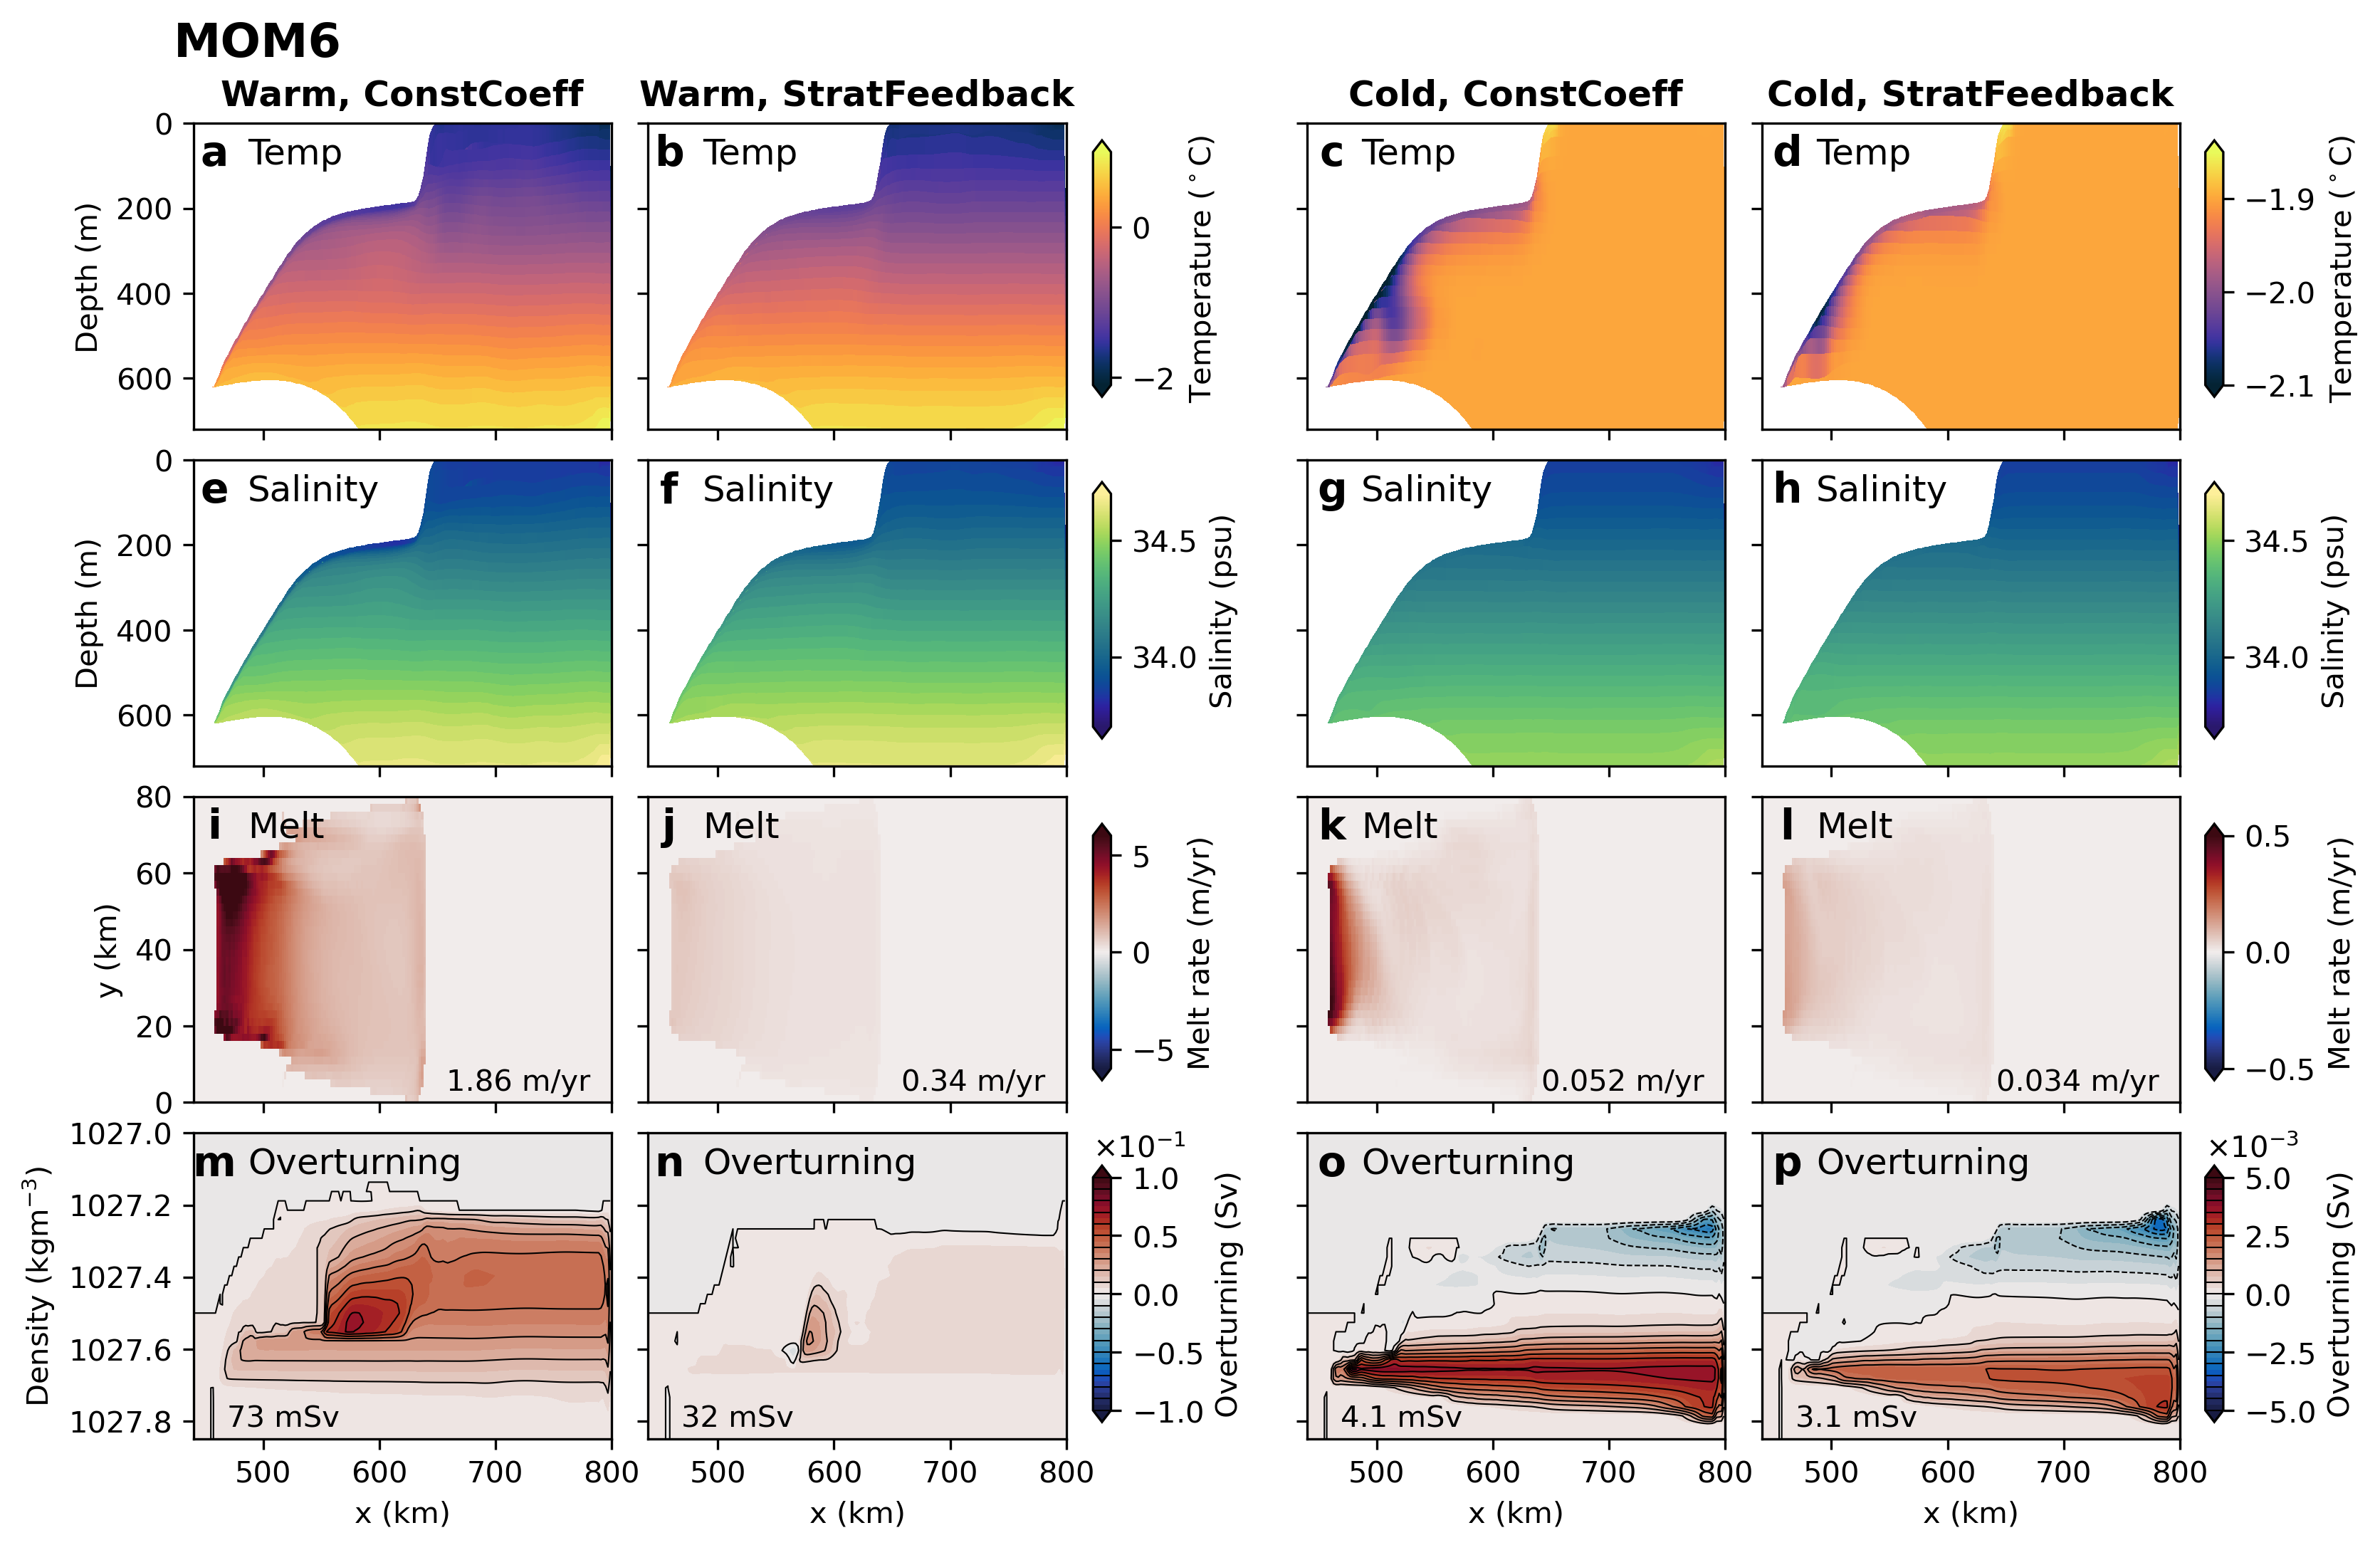

In [10]:
fig, axes = plt.subplots(nrows = 4, ncols = 5,figsize = (12,8),dpi = 300, 
                         width_ratios = [1,1,0.4,1,1])

y = 20
x = 20

prog, ocean_geometry = open_files_MOM6(0)
j = 0
wT = plot_MOM6(axes[0,0],x,j,prog.temp,"T ($^\circ$C)",-2.1,1,cm.cm.thermal)
wS = plot_MOM6(axes[1,0],x,j,prog.salt,"S (psu)",33.7,34.7,cm.cm.haline)
wm,me = plot_melt_MOM6(axes[2,0],j,-6,6,cm.cm.balance)
axes[2,0].text(0.95,0.02,f'{me:.2f}'+' m/yr',transform = axes[2,0].transAxes, ha = 'right',va = 'bottom')
otw,otwl,osf0 = plot_rhooverturning_MOM6(axes[3,0],j,-0.1,0.1,cm.cm.balance)
axes[3,0].text(0.08,0.02,f'{osf0*1e3:.0f}'+' mSv',transform = axes[3,0].transAxes, ha = 'left',va = 'bottom')

prog, ocean_geometry = open_files_MOM6(2)
j = 2
plot_MOM6(axes[0,1],x,j,prog.temp,"T ($^\circ$C)",-2.1,1,cm.cm.thermal)
plot_MOM6(axes[1,1],x,j,prog.salt,"S (psu)",33.7,34.7,cm.cm.haline)
wm,me = plot_melt_MOM6(axes[2,1],j,-6,6,cm.cm.balance)
axes[2,1].text(0.95,0.02,f'{me:.2f}'+' m/yr',transform = axes[2,1].transAxes, ha = 'right',va = 'bottom')
otw,otwl,osf0 = plot_rhooverturning_MOM6(axes[3,1],j,-0.1,0.1,cm.cm.balance)
axes[3,1].text(0.08,0.02,f'{osf0*1e3:.0f}'+' mSv',transform = axes[3,1].transAxes, ha = 'left',va = 'bottom')
# plot_rhooverturning_MOM6(axes[5,0],j,-0.02,0.02,cm.cm.balance)


prog, ocean_geometry = open_files_MOM6(1)
j = 1
cT = plot_MOM6(axes[0,3],x,j,prog.temp,"T ($^\circ$C)",-2.1,-1.85,cm.cm.thermal)
cS = plot_MOM6(axes[1,3],x,j,prog.salt,"S (psu)",33.7,34.7,cm.cm.haline)
wc,me = plot_melt_MOM6(axes[2,3],j,-0.5,0.5,cm.cm.balance)
axes[2,3].text(0.95,0.02,f'{me:.3f}'+' m/yr',transform = axes[2,3].transAxes, ha = 'right',va = 'bottom')
otc,otcl,osf0 = plot_rhooverturning_MOM6(axes[3,3],j,-0.005,0.005,cm.cm.balance)
axes[3,3].text(0.08,0.02,f'{osf0*1e3:.1f}'+' mSv',transform = axes[3,3].transAxes, ha = 'left',va = 'bottom')
# plot_rhooverturning_MOM6(axes[4,1],j,-0.2,0.2,cm.cm.balance)

prog, ocean_geometry = open_files_MOM6(3)
j = 3
plot_MOM6(axes[0,4],x,j,prog.temp,"T ($^\circ$C)",-2.1,-1.85,cm.cm.thermal)
plot_MOM6(axes[1,4],x,j,prog.salt,"S (psu)",33.7,34.7,cm.cm.haline)
wc,me = plot_melt_MOM6(axes[2,4],j,-0.5,0.5,cm.cm.balance)
axes[2,4].text(0.95,0.02,f'{me:.3f}'+' m/yr',transform = axes[2,4].transAxes, ha = 'right',va = 'bottom')
otc,otcl,osf0 = plot_rhooverturning_MOM6(axes[3,4],j,-0.005,0.005,cm.cm.balance)
axes[3,4].text(0.08,0.02,f'{osf0*1e3:.1f}'+' mSv',transform = axes[3,4].transAxes, ha = 'left',va = 'bottom')
# plot_rhooverturning_MOM6(axes[5,1],j,-0.02,0.02,cm.cm.balance)


caxwT = plt.axes([0.476,0.72,0.007,0.15])
plt.colorbar(wT, cax = caxwT, label = 'Temperature ($^\circ$C)', extend = 'both')
caxcT = plt.axes([0.91,0.72,0.007,0.15])
plt.colorbar(cT, cax = caxcT, label = 'Temperature ($^\circ$C)', extend = 'both')
caxwS = plt.axes([0.476,0.52,0.007,0.15])
plt.colorbar(wS, cax = caxwS, label = 'Salinity (psu)', extend = 'both')
caxcS = plt.axes([0.91,0.52,0.007,0.15])
plt.colorbar(cS, cax = caxcS, label = 'Salinity (psu)', extend = 'both')
caxwm = plt.axes([0.476,0.32,0.007,0.15])
plt.colorbar(wm, cax = caxwm, label = 'Melt rate (m/yr)', extend = 'both')
caxcm = plt.axes([0.91,0.32,0.007,0.15])
plt.colorbar(wc, cax = caxcm, label = 'Melt rate (m/yr)', extend = 'both')

caxwT2 = plt.axes([0.476,0.12,0.007,0.15])
cbar = plt.colorbar(otw, cax = caxwT2, label = 'Overturning (Sv)')
cbar.add_lines(otwl)
cbar.set_ticks([-1e-1,-5e-2,0,5e-2,1e-1])
cbar.formatter.set_powerlimits((0, 0))
cbar.formatter.set_useMathText(True)
cbar.ax.yaxis.set_offset_position('left')
cbar.update_ticks()

caxcT2 = plt.axes([0.91,0.12,0.007,0.15])
cbar = plt.colorbar(otc, cax = caxcT2, label = 'Overturning (Sv)')
cbar.add_lines(otcl)
cbar.set_ticks([-5e-3,-2.5e-3,0,2.5e-3,5e-3])
cbar.formatter.set_powerlimits((0, 0))
cbar.formatter.set_useMathText(True)
cbar.ax.yaxis.set_offset_position('left')
cbar.update_ticks()

for k in np.arange(4):
    axes[k,2].axis('off')
for j in np.array([0,1,3,4]):
    axes[3,j].set_yticks([1027.8,1027.6,1027.4,1027.2,1027.0])
    axes[3,j].set_yticklabels(['1027.8','1027.6','1027.4','1027.2','1027.0'])    

    
fig.subplots_adjust(wspace = 0.1,hspace = 0.1)

axes[0,0].set_title('Warm, ConstCoeff',fontweight='bold')# \n Warm, T')
axes[0,1].set_title('Warm, StratFeedback',fontweight='bold')# \n Warm, T')
axes[0,3].set_title('Cold, ConstCoeff',fontweight='bold')# \n Warm, T')
axes[0,4].set_title('Cold, StratFeedback',fontweight='bold')# \n Warm, T')


for j in np.arange(1,5):
    for k in np.arange(4):
        axes[k,j].set_ylabel('')
        axes[k,j].yaxis.set_ticklabels([])
    # for k in np.arange(4,6):
    #     axes[k,j].yaxis.set_ticklabels([])

for j in np.arange(5):
    for k in np.arange(3):
        axes[k,j].set_xlabel('')
        axes[k,j].xaxis.set_ticklabels([])
        
for j in np.arange(2):
    axes[0,j].text(0.13,0.9,'Temp',horizontalalignment='left', # fontweight='bold',
             verticalalignment='center',transform=axes[0,j].transAxes, fontsize = 12)
    axes[1,j].text(0.13,0.9,'Salinity',horizontalalignment='left', # fontweight='bold',
             verticalalignment='center',transform=axes[1,j].transAxes, fontsize = 12)
    axes[2,j].text(0.13,0.9,'Melt',horizontalalignment='left', # fontweight='bold',
             verticalalignment='center',transform=axes[2,j].transAxes, fontsize = 12)
    axes[3,j].text(0.13,0.9,'Overturning',horizontalalignment='left', # fontweight='bold',
             verticalalignment='center',transform=axes[3,j].transAxes, fontsize = 12)
    for k in np.arange(4):
        if (k>0):
            axes[k,j].set_title('')
        alph = ['a','b','c','d','e','f','g','h','i','j','k','l','m','n','o',
                'p','q']
        
        axes[k,j].set_xlim(440,800)
        axes[k,j].text(0.05,0.9,alph[k*4+j],horizontalalignment='center', fontweight='bold',
             verticalalignment='center',transform=axes[k,j].transAxes, fontsize = 14)
for j in np.arange(3,5):
    axes[0,j].text(0.13,0.9,'Temp',horizontalalignment='left', # fontweight='bold',
             verticalalignment='center',transform=axes[0,j].transAxes, fontsize = 12)
    axes[1,j].text(0.13,0.9,'Salinity',horizontalalignment='left', # fontweight='bold',
             verticalalignment='center',transform=axes[1,j].transAxes, fontsize = 12)
    axes[2,j].text(0.13,0.9,'Melt',horizontalalignment='left', # fontweight='bold',
             verticalalignment='center',transform=axes[2,j].transAxes, fontsize = 12)
    axes[3,j].text(0.13,0.9,'Overturning',horizontalalignment='left', # fontweight='bold',
             verticalalignment='center',transform=axes[3,j].transAxes, fontsize = 12)

    for k in np.arange(4):
        if (k>0):
            axes[k,j].set_title('')
        alph = ['a','b','c','d','e','f','g','h','i','j','k','l','m','n','o',
                'p','q']
        
        axes[k,j].set_xlim(440,800)
        axes[k,j].text(0.06,0.9,alph[k*4+j-1],horizontalalignment='center', fontweight='bold',
             verticalalignment='center',transform=axes[k,j].transAxes, fontsize = 14)
    
        
#fig.align_ylabels([axes[0,0],axes[1,0],axes[2,0],axes[3,0]])
fig.align_ylabels([caxwT,caxwS,caxwm,caxwT2])
fig.align_ylabels([caxcT,caxcS,caxcm,caxcT2])

fig.suptitle('MOM6', fontweight='bold', x = 0.15,y=0.94,fontsize = 16)
fig.savefig('/g/data/x77/cy8964/ISOMIP/param-paper-plots/figs/Fig4.png', dpi = 300)

Total Melt for run-J10-warm-utide experiment = 3.328413 m/yr
run-J10-warm-utide
Max Psi = 0.08571098876792435 Sv
Total Melt for run-R22-warm-utide experiment = 0.7371485 m/yr
run-R22-warm-utide
Max Psi = 0.019678063287469103 Sv
Total Melt for run-J10-cold-utide experiment = 0.06166205 m/yr
run-J10-cold-utide
Max Psi = 0.004903252798684502 Sv
Total Melt for run-R22-cold-utide experiment = 0.03578575 m/yr
run-R22-cold-utide
Max Psi = 0.0034580380918827172 Sv


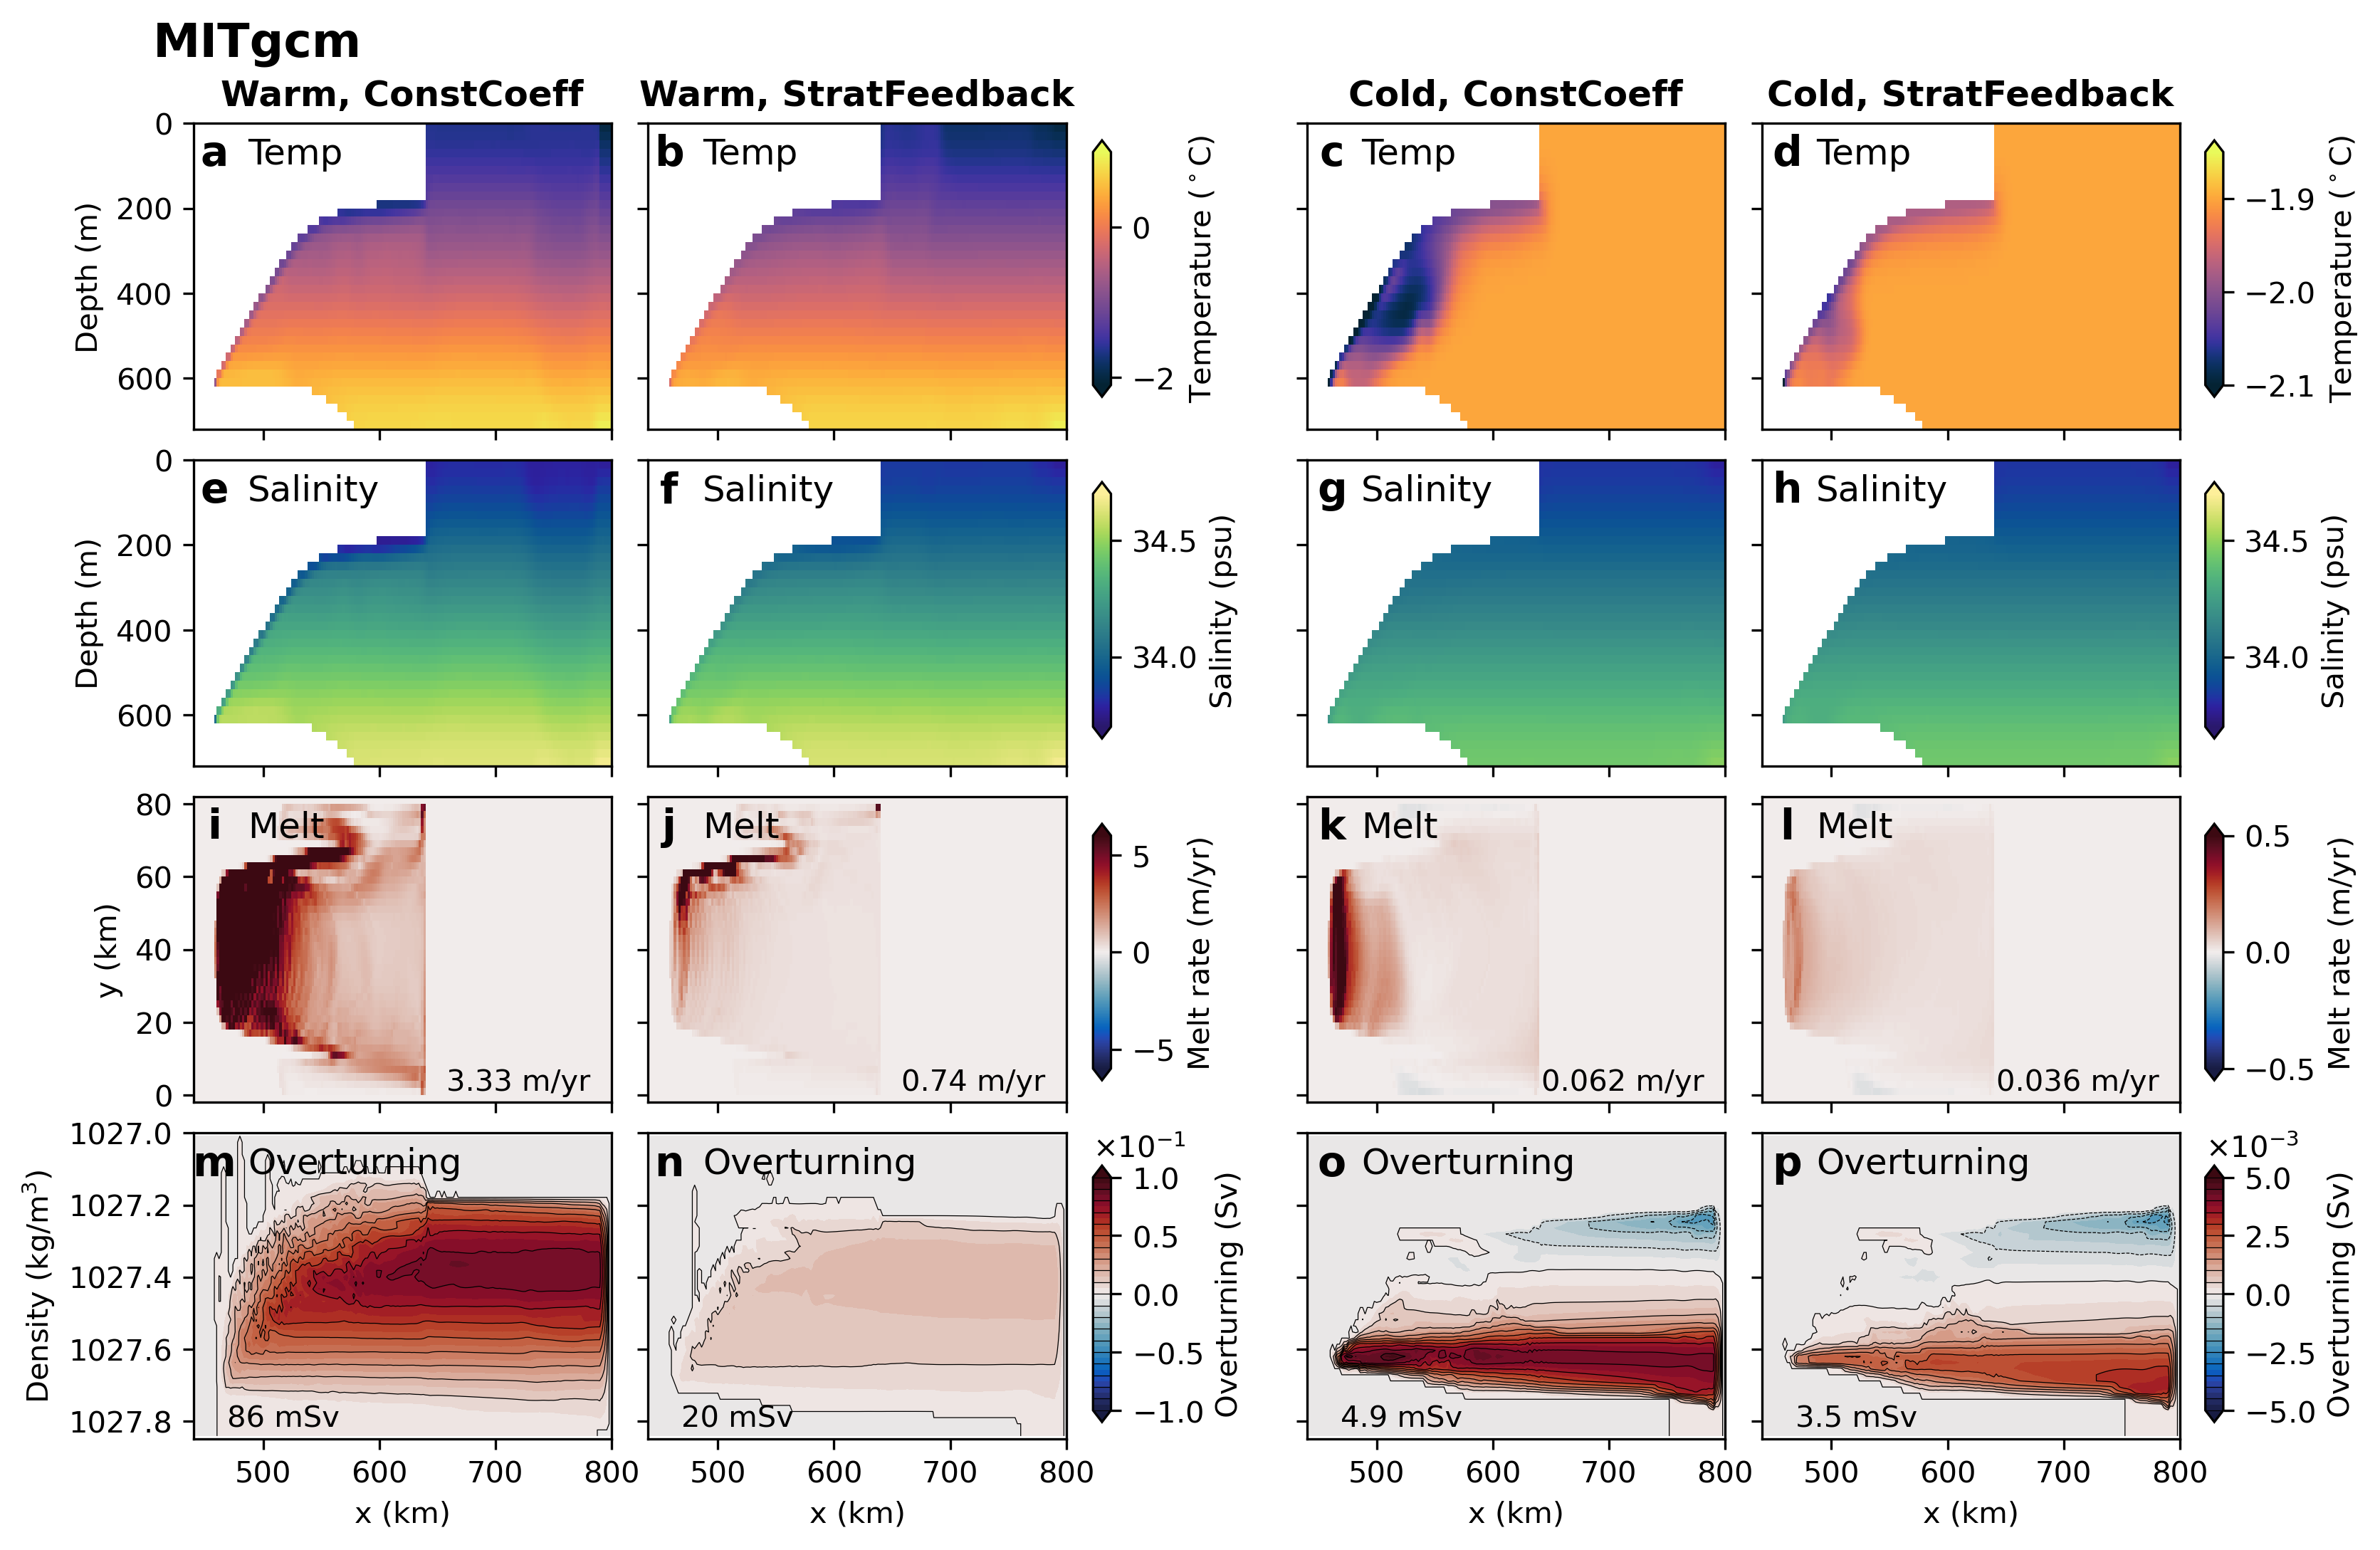

In [11]:
# MIT plot only
fig, axes = plt.subplots(nrows = 4, ncols = 5,figsize = (12,8),dpi = 300, 
                         width_ratios = [1,1,0.4,1,1])


y = 20
x = 20

j = 0
wT = plot_transect_MIT(axes[0,0], j, y, 'Ttave',  -2.1, 1, cm.cm.thermal)
wS = plot_transect_MIT(axes[1,0], j, y, 'Stave',  33.7,34.7, cm.cm.haline)
wm, me = plot_melt_MIT(axes[2,0], j,  -6,6)
axes[2,0].text(0.95,0.02,f'{me:.2f}'+' m/yr',transform = axes[2,0].transAxes, ha = 'right',va = 'bottom')
otw, otwl,osf0 = plot_rhooverturning_MITnew(axes[3,0],j,  -0.1,0.1)
axes[3,0].text(0.08,0.02,f'{osf0*1e3:.0f}'+' mSv',transform = axes[3,0].transAxes, ha = 'left',va = 'bottom')

j = 1
plot_transect_MIT(axes[0,1], j, y, 'Ttave',  -2.1, 1, cm.cm.thermal)
plot_transect_MIT(axes[1,1], j, y, 'Stave',  33.7,34.7, cm.cm.haline)
wm, me = plot_melt_MIT(axes[2,1], j, -6,6)
axes[2,1].text(0.95,0.02,f'{me:.2f}'+' m/yr',transform = axes[2,1].transAxes, ha = 'right',va = 'bottom')
otw, otwl,osf0 = plot_rhooverturning_MITnew(axes[3,1],j,  -0.1,0.1)
axes[3,1].text(0.08,0.02,f'{osf0*1e3:.0f}'+' mSv',transform = axes[3,1].transAxes, ha = 'left',va = 'bottom')


j = 2
cT = plot_transect_MIT(axes[0,3], j, y, 'Ttave', -2.1,-1.85,cm.cm.thermal)
cS = plot_transect_MIT(axes[1,3], j, y, 'Stave', 33.7,34.7,cm.cm.haline)
wc,me = plot_melt_MIT(axes[2,3],j,-0.5,0.5)
axes[2,3].text(0.95,0.02,f'{me:.3f}'+' m/yr',transform = axes[2,3].transAxes, ha = 'right',va = 'bottom')
otc, otcl,osf0 = plot_rhooverturning_MITnew(axes[3,3],j,  -0.005,0.005)
axes[3,3].text(0.08,0.02,f'{osf0*1e3:.1f}'+' mSv',transform = axes[3,3].transAxes, ha = 'left',va = 'bottom')

j = 3
cT = plot_transect_MIT(axes[0,4], j, y, 'Ttave',-2.1,-1.85,cm.cm.thermal)
cS = plot_transect_MIT(axes[1,4], j, y, 'Stave', 33.7,34.7,cm.cm.haline)
wc,me = plot_melt_MIT(axes[2,4],j,-0.5,0.5)
axes[2,4].text(0.95,0.02,f'{me:.3f}'+' m/yr',transform = axes[2,4].transAxes, ha = 'right',va = 'bottom')
otc, otcl, osf0 = plot_rhooverturning_MITnew(axes[3,4],j,  -0.005,0.005)
axes[3,4].text(0.08,0.02,f'{osf0*1e3:.1f}'+' mSv',transform = axes[3,4].transAxes, ha = 'left',va = 'bottom')
# plot_rhooverturning_MOM6(axes[5,1],j,-0.02,0.02,cm.cm.balance)


caxwT = plt.axes([0.476,0.72,0.007,0.15])
plt.colorbar(wT, cax = caxwT, label = 'Temperature ($^\circ$C)', extend = 'both')
caxcT = plt.axes([0.91,0.72,0.007,0.15])
plt.colorbar(cT, cax = caxcT, label = 'Temperature ($^\circ$C)', extend = 'both')
caxwS = plt.axes([0.476,0.52,0.007,0.15])
plt.colorbar(wS, cax = caxwS, label = 'Salinity (psu)', extend = 'both')
caxcS = plt.axes([0.91,0.52,0.007,0.15])
plt.colorbar(cS, cax = caxcS, label = 'Salinity (psu)', extend = 'both')
caxwm = plt.axes([0.476,0.32,0.007,0.15])
plt.colorbar(wm, cax = caxwm, label = 'Melt rate (m/yr)', extend = 'both')
caxcm = plt.axes([0.91,0.32,0.007,0.15])
plt.colorbar(wc, cax = caxcm, label = 'Melt rate (m/yr)', extend = 'both')

caxwT2 = plt.axes([0.476,0.12,0.007,0.15])
cbar = plt.colorbar(otw, cax = caxwT2, label = 'Overturning (Sv)')
cbar.add_lines(otwl)
cbar.set_ticks([-1e-1,-5e-2,0,5e-2,1e-1])
cbar.formatter.set_powerlimits((0, 0))
cbar.formatter.set_useMathText(True)
cbar.ax.yaxis.set_offset_position('left')
cbar.update_ticks()

caxcT2 = plt.axes([0.91,0.12,0.007,0.15])
cbar = plt.colorbar(otc, cax = caxcT2, label = 'Overturning (Sv)')
cbar.add_lines(otcl)
cbar.set_ticks([-5e-3,-2.5e-3,0,2.5e-3,5e-3])
cbar.formatter.set_powerlimits((0, 0))
cbar.formatter.set_useMathText(True)
cbar.ax.yaxis.set_offset_position('left')
cbar.update_ticks()

for k in np.arange(4):
    axes[k,2].axis('off')
for j in np.array([0,1,3,4]):
    axes[3,j].set_yticks([1027.8,1027.6,1027.4,1027.2,1027.0])
    axes[3,j].set_yticklabels(['1027.8','1027.6','1027.4','1027.2','1027.0'])    

    
fig.subplots_adjust(wspace = 0.1,hspace = 0.1)

axes[0,0].set_title('Warm, ConstCoeff',fontweight='bold')# \n Warm, T')
axes[0,1].set_title('Warm, StratFeedback',fontweight='bold')# \n Warm, T')
axes[0,3].set_title('Cold, ConstCoeff',fontweight='bold')# \n Warm, T')
axes[0,4].set_title('Cold, StratFeedback',fontweight='bold')# \n Warm, T')


for j in np.arange(1,5):
    for k in np.arange(4):
        axes[k,j].set_ylabel('')
        axes[k,j].yaxis.set_ticklabels([])
    # for k in np.arange(4,6):
    #     axes[k,j].yaxis.set_ticklabels([])

for j in np.arange(5):
    for k in np.arange(3):
        axes[k,j].set_xlabel('')
        axes[k,j].xaxis.set_ticklabels([])
        
for j in np.arange(2):
    axes[0,j].text(0.13,0.9,'Temp',horizontalalignment='left', # fontweight='bold',
             verticalalignment='center',transform=axes[0,j].transAxes, fontsize = 12)
    axes[1,j].text(0.13,0.9,'Salinity',horizontalalignment='left', # fontweight='bold',
             verticalalignment='center',transform=axes[1,j].transAxes, fontsize = 12)
    axes[2,j].text(0.13,0.9,'Melt',horizontalalignment='left', # fontweight='bold',
             verticalalignment='center',transform=axes[2,j].transAxes, fontsize = 12)
    axes[3,j].text(0.13,0.9,'Overturning',horizontalalignment='left', # fontweight='bold',
             verticalalignment='center',transform=axes[3,j].transAxes, fontsize = 12)
    for k in np.arange(4):
        if (k>0):
            axes[k,j].set_title('')
        alph = ['a','b','c','d','e','f','g','h','i','j','k','l','m','n','o',
                'p','q']
        
        axes[k,j].set_xlim(440,800)
        axes[k,j].text(0.05,0.9,alph[k*4+j],horizontalalignment='center', fontweight='bold',
             verticalalignment='center',transform=axes[k,j].transAxes, fontsize = 14)
for j in np.arange(3,5):
    axes[0,j].text(0.13,0.9,'Temp',horizontalalignment='left', # fontweight='bold',
             verticalalignment='center',transform=axes[0,j].transAxes, fontsize = 12)
    axes[1,j].text(0.13,0.9,'Salinity',horizontalalignment='left', # fontweight='bold',
             verticalalignment='center',transform=axes[1,j].transAxes, fontsize = 12)
    axes[2,j].text(0.13,0.9,'Melt',horizontalalignment='left', # fontweight='bold',
             verticalalignment='center',transform=axes[2,j].transAxes, fontsize = 12)
    axes[3,j].text(0.13,0.9,'Overturning',horizontalalignment='left', # fontweight='bold',
             verticalalignment='center',transform=axes[3,j].transAxes, fontsize = 12)

    for k in np.arange(4):
        if (k>0):
            axes[k,j].set_title('')
        alph = ['a','b','c','d','e','f','g','h','i','j','k','l','m','n','o',
                'p','q']
        
        axes[k,j].set_xlim(440,800)
        axes[k,j].text(0.06,0.9,alph[k*4+j-1],horizontalalignment='center', fontweight='bold',
             verticalalignment='center',transform=axes[k,j].transAxes, fontsize = 14)
    
        
#fig.align_ylabels([axes[0,0],axes[1,0],axes[2,0],axes[3,0]])
fig.align_ylabels([caxwT,caxwS,caxwm,caxwT2])
fig.align_ylabels([caxcT,caxcS,caxcm,caxcT2])

fig.suptitle('MITgcm', fontweight='bold', x = 0.15,y=0.94,fontsize = 16)
fig.savefig('/g/data/x77/cy8964/ISOMIP/param-paper-plots/figs/FigC1.png', dpi = 300)